# Reward Duration Experiment v2

Notebook для аналізу оновленого другого BehaviourSpace-експерименту.

Основні фактори:

- `reward-duration`
- `high-reward-salience`
- `crowding-out-rate`
- `habit-learning-rate`

Фіксовані параметри:

- `reward-cycles = 1`
- `withdrawal-duration = 60`
- `low-reward-salience = 0.3`
- `number-of-shoppers = 900`

## Підготовка середовища

```bash
python -m pip install pandas numpy matplotlib scipy scikit-learn statsmodels
```

In [4]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

OUTPUT_DIR = Path("./analysis_output/2-reward_duration")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/igor/projects/phd/reward-habits-model/analysis_output/2-reward_duration


## Конфігурація

In [5]:
CSV_PATH = Path("./experiments/2-reward-duration/table.csv")

FACTORS = [
    "reward-duration",
    "high-reward-salience",
    "crowding-out-rate",
    "habit-learning-rate",
]

FIXED_PARAMETERS = [
    "reward-cycles",
    "withdrawal-duration",
    "low-reward-salience",
    "number-of-shoppers",
]

PRIMARY_TARGET = "high-reward-crowding-out-effect"
SECONDARY_TARGET = "low-reward-persistence-effect"

FINAL_WITHDRAWAL_METRICS = [
    'final-withdrawal-choice-rate "control"',
    'final-withdrawal-choice-rate "low-salience"',
    'final-withdrawal-choice-rate "high-salience"',
]

MOTIVATION_METRICS = [
    'mean-intrinsic-motivation "control"',
    'mean-intrinsic-motivation "low-salience"',
    'mean-intrinsic-motivation "high-salience"',
]

HABIT_METRICS = [
    'mean-habit "control"',
    'mean-habit "low-salience"',
    'mean-habit "high-salience"',
]

RETENTION_METRICS = [
    "high-reward-retention-ratio",
    "low-reward-retention-ratio",
]

WITHDRAWAL_DROP_METRICS = [
    "high-reward-withdrawal-drop",
    "low-reward-withdrawal-drop",
]

## Завантаження даних

In [6]:
df = pd.read_csv(CSV_PATH, skiprows=6)
df.columns = df.columns.astype(str).str.strip()

print("Shape:", df.shape)
print("\nColumns:")
for column in df.columns:
    print("-", column)

df.head()

Shape: (2700, 25)

Columns:
- [run number]
- reward-cycles
- reward-duration
- high-reward-salience
- crowding-out-rate
- habit-learning-rate
- withdrawal-duration
- low-reward-salience
- number-of-shoppers
- [step]
- high-reward-crowding-out-effect
- low-reward-persistence-effect
- final-withdrawal-choice-rate "control"
- final-withdrawal-choice-rate "low-salience"
- final-withdrawal-choice-rate "high-salience"
- mean-intrinsic-motivation "control"
- mean-intrinsic-motivation "low-salience"
- mean-intrinsic-motivation "high-salience"
- mean-habit "control"
- mean-habit "low-salience"
- mean-habit "high-salience"
- high-reward-withdrawal-drop
- low-reward-withdrawal-drop
- high-reward-retention-ratio
- low-reward-retention-ratio


,[run number],reward-cycles,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,withdrawal-duration,low-reward-salience,number-of-shoppers,[step],high-reward-crowding-out-effect,low-reward-persistence-effect,"final-withdrawal-choice-rate ""control""","final-withdrawal-choice-rate ""low-salience""","final-withdrawal-choice-rate ""high-salience""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""",high-reward-withdrawal-drop,low-reward-withdrawal-drop,high-reward-retention-ratio,low-reward-retention-ratio
0,3,1,15,0.7,0.01,0.005,60,0.3,1000,105,0.035019,0.046981,0.544711,0.591692,0.579730,0.486388,0.518306,0.497846,0.152014,0.214028,0.222063,0.258709,0.128428,0.691440,0.821657
1,4,1,15,0.7,0.01,0.005,60,0.3,1000,105,-0.004774,0.016797,0.560130,0.576927,0.555355,0.501006,0.518317,0.473191,0.179643,0.205394,0.209806,0.266066,0.119770,0.676091,0.828089
2,7,1,15,0.7,0.01,0.005,60,0.3,1000,105,0.050261,0.030241,0.536926,0.567167,0.587187,0.478842,0.507343,0.498825,0.151748,0.194736,0.232491,0.252252,0.127528,0.699499,0.816427
3,9,1,15,0.7,0.01,0.005,60,0.3,1000,105,0.018642,0.001275,0.557934,0.559209,0.576577,0.504981,0.499083,0.486527,0.162553,0.186537,0.219126,0.251251,0.132683,0.696493,0.808232
4,6,1,15,0.7,0.01,0.005,60,0.3,1000,105,0.015418,0.008061,0.567565,0.575626,0.582983,0.512149,0.507098,0.497954,0.176211,0.203741,0.236880,0.254855,0.126076,0.695818,0.820328


## Перевірка структури

In [7]:
required_columns = (
    ["[run number]"]
    + FACTORS
    + FIXED_PARAMETERS
    + [PRIMARY_TARGET, SECONDARY_TARGET]
    + FINAL_WITHDRAWAL_METRICS
    + MOTIVATION_METRICS
    + HABIT_METRICS
    + RETENTION_METRICS
    + WITHDRAWAL_DROP_METRICS
)

missing = [c for c in required_columns if c not in df.columns]

if missing:
    print("Відсутні колонки:")
    for c in missing:
        print("-", c)
else:
    print("Усі очікувані колонки присутні.")

Усі очікувані колонки присутні.


## Очищення даних

In [8]:
numeric_columns = (
    FACTORS
    + FIXED_PARAMETERS
    + [PRIMARY_TARGET, SECONDARY_TARGET]
    + FINAL_WITHDRAWAL_METRICS
    + MOTIVATION_METRICS
    + HABIT_METRICS
    + RETENTION_METRICS
    + WITHDRAWAL_DROP_METRICS
)

clean_df = df.copy()

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

before = len(clean_df)

clean_df = clean_df.dropna(
    subset=FACTORS + [PRIMARY_TARGET, SECONDARY_TARGET]
).copy()

print("Rows before:", before)
print("Rows after:", len(clean_df))
print("Removed:", before - len(clean_df))

Rows before: 2700
Rows after: 2700
Removed: 0


## Перевірка дизайну

In [9]:
design_counts = (
    clean_df.groupby(FACTORS)
    .size()
    .reset_index(name="repetitions")
)

print("Parameter combinations:", len(design_counts))
print("Minimum repetitions:", design_counts["repetitions"].min())
print("Maximum repetitions:", design_counts["repetitions"].max())

if design_counts["repetitions"].nunique() == 1:
    print("Дизайн збалансований.")
else:
    print("Увага: дизайн незбалансований.")

design_counts.head()

Parameter combinations: 135
Minimum repetitions: 20
Maximum repetitions: 20
Дизайн збалансований.


,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,repetitions
0,15,0.7,0.01,0.005,20
1,15,0.7,0.01,0.020,20
2,15,0.7,0.01,0.050,20
3,15,0.7,0.03,0.005,20
4,15,0.7,0.03,0.020,20


In [10]:
for parameter in FIXED_PARAMETERS:
    print(parameter, sorted(clean_df[parameter].dropna().unique()))

reward-cycles [np.int64(1)]
withdrawal-duration [np.int64(60)]
low-reward-salience [np.float64(0.3)]
number-of-shoppers [np.int64(1000)]


## Описова статистика

In [11]:
summary_metrics = (
    [PRIMARY_TARGET, SECONDARY_TARGET]
    + FINAL_WITHDRAWAL_METRICS
    + MOTIVATION_METRICS
    + HABIT_METRICS
    + RETENTION_METRICS
    + WITHDRAWAL_DROP_METRICS
)

clean_df[summary_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
high-reward-crowding-out-effect,2700.0,-0.048997,0.082611,-0.313025,-0.092228,-0.028247,0.008051,0.130109
low-reward-persistence-effect,2700.0,0.051286,0.034932,-0.014743,0.025206,0.043706,0.069739,0.164831
"final-withdrawal-choice-rate ""control""",2700.0,0.695656,0.103016,0.523503,0.561527,0.740095,0.790220,0.819311
"final-withdrawal-choice-rate ""low-salience""",2700.0,0.746942,0.091259,0.549349,0.665853,0.794244,0.823636,0.856306
"final-withdrawal-choice-rate ""high-salience""",2700.0,0.646659,0.108336,0.345345,0.567092,0.666517,0.739252,0.804705
"mean-intrinsic-motivation ""control""",2700.0,0.499877,0.008231,0.472412,0.494301,0.499748,0.505537,0.527820
"mean-intrinsic-motivation ""low-salience""",2700.0,0.546496,0.029784,0.484014,0.519757,0.544474,0.571744,0.615864
"mean-intrinsic-motivation ""high-salience""",2700.0,0.352698,0.117336,0.051014,0.279329,0.384504,0.447992,0.509350
"mean-habit ""control""",2700.0,0.644989,0.340703,0.135696,0.181119,0.810970,0.956377,0.968453
"mean-habit ""low-salience""",2700.0,0.717471,0.296913,0.173330,0.380674,0.892083,0.963811,0.978424


## Допоміжні функції

In [12]:
def main_effect_summary(data, factor, target):
    result = (
        data.groupby(factor)[target]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    result["se"] = result["std"] / np.sqrt(result["count"])
    result["ci95"] = 1.96 * result["se"]
    return result


def plot_main_effect(data, factor, target, title=None):
    result = main_effect_summary(data, factor, target)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(
        result[factor],
        result["mean"],
        yerr=result["ci95"],
        marker="o",
        capsize=4,
    )
    ax.axhline(0, linewidth=1)
    ax.set_title(title or f"Main effect of {factor}")
    ax.set_xlabel(factor)
    ax.set_ylabel(target)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"main_effect_{factor}.png", dpi=200)
    plt.show()

    return result


def plot_interaction(data, x, group, target, title=None):
    result = (
        data.groupby([x, group])[target]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    for value in sorted(result[group].unique()):
        subset = result[result[group] == value]
        ax.plot(
            subset[x],
            subset[target],
            marker="o",
            label=f"{group} = {value}",
        )

    ax.axhline(0, linewidth=1)
    ax.set_title(title or f"Interaction: {x} × {group}")
    ax.set_xlabel(x)
    ax.set_ylabel(target)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"interaction_{x}_{group}.png", dpi=200)
    plt.show()

    return result

## Головний ефект reward duration

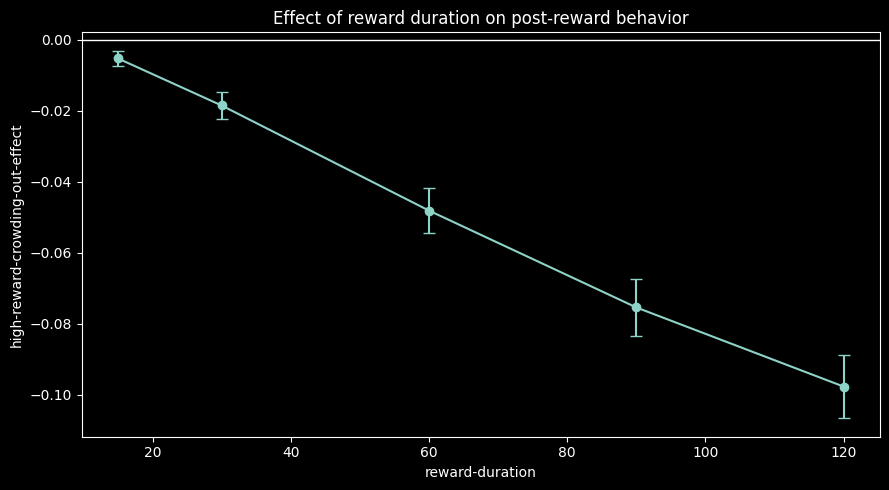

,reward-duration,mean,std,count,se,ci95
0,15,-0.005312,0.025770,540,0.001109,0.002174
1,30,-0.018548,0.044795,540,0.001928,0.003778
2,60,-0.048120,0.074919,540,0.003224,0.006319
3,90,-0.075369,0.093645,540,0.004030,0.007899
4,120,-0.097637,0.105885,540,0.004557,0.008931


In [13]:
duration_summary = plot_main_effect(
    clean_df,
    "reward-duration",
    PRIMARY_TARGET,
    "Effect of reward duration on post-reward behavior",
)

duration_summary

## Головні ефекти всіх факторів

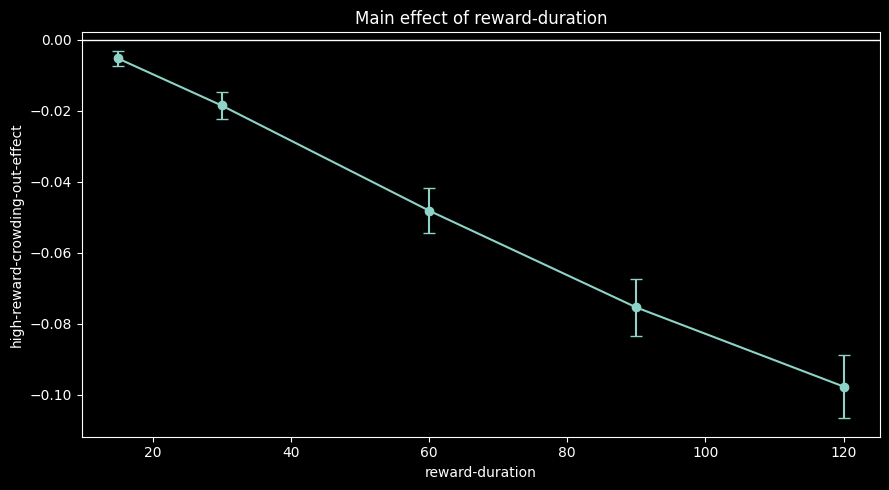

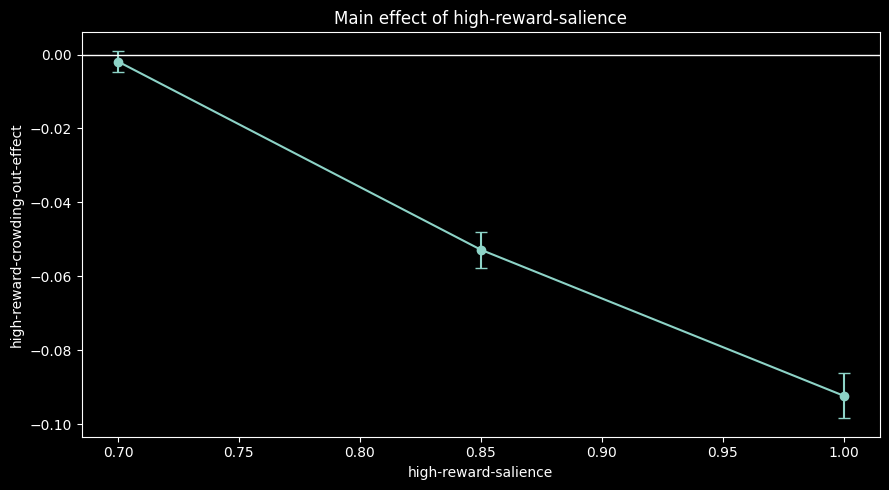

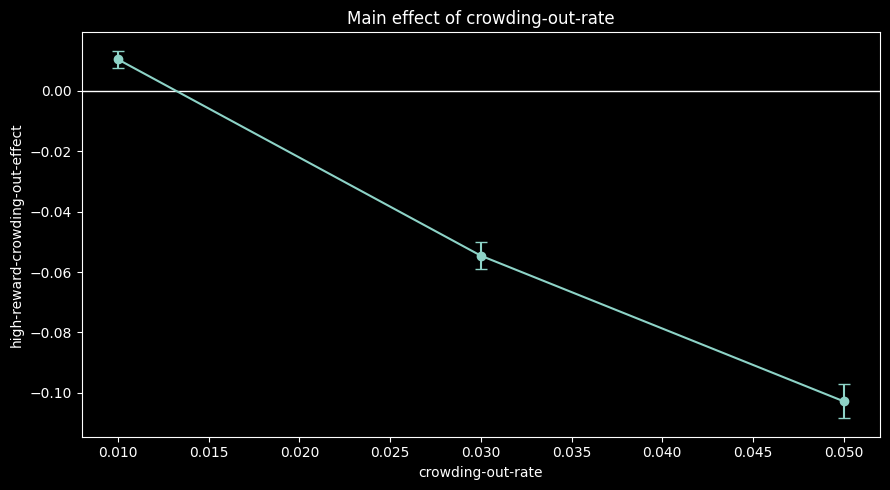

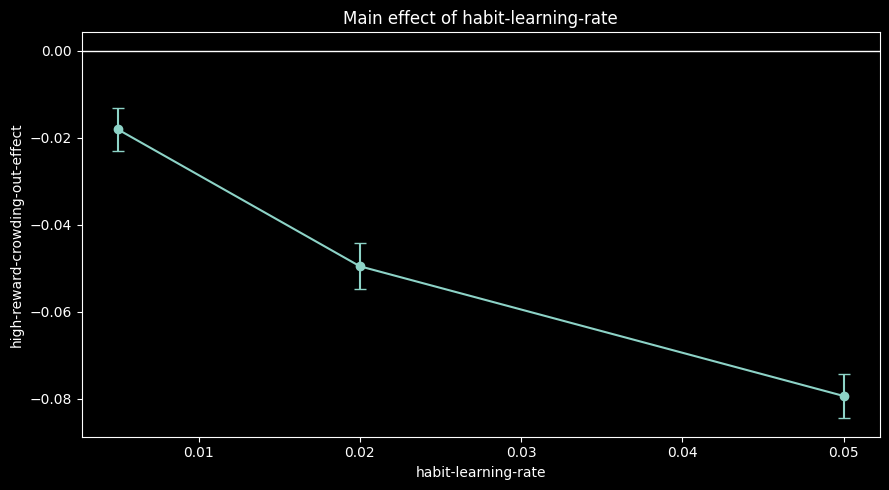

In [14]:
main_effect_tables = {}

for factor in FACTORS:
    main_effect_tables[factor] = plot_main_effect(
        clean_df,
        factor,
        PRIMARY_TARGET,
    )

## Interaction plots

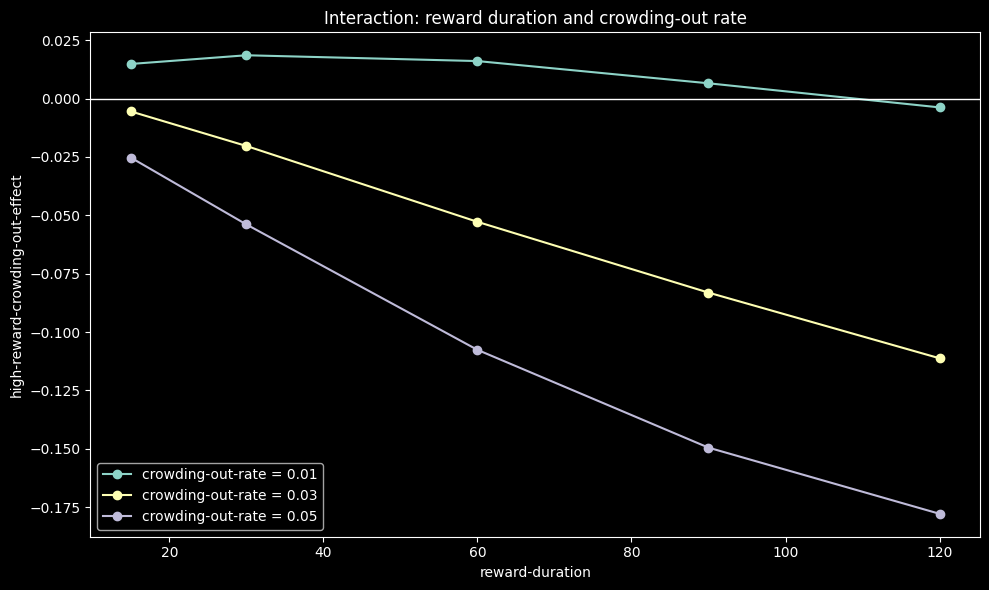

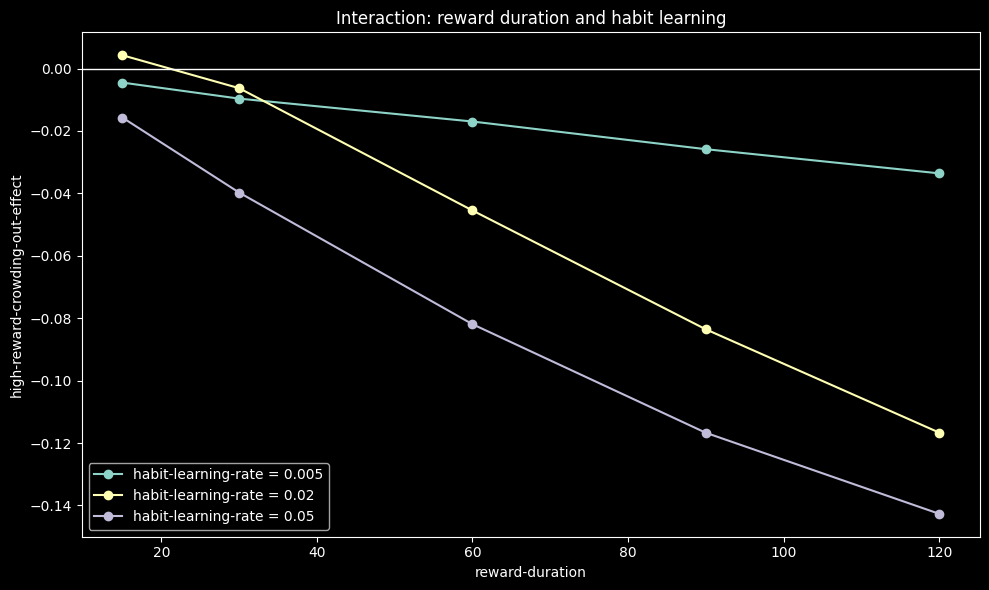

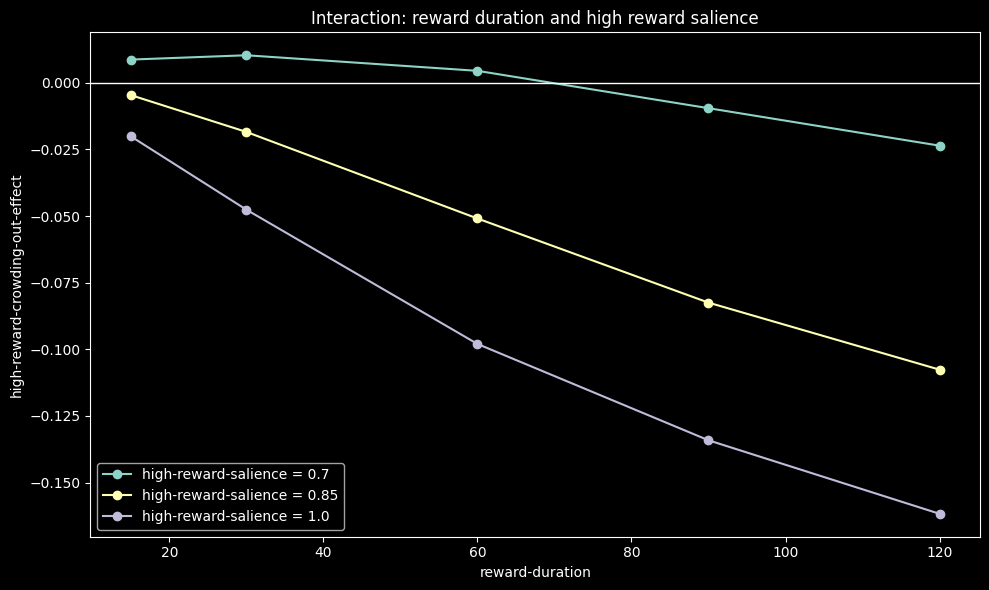

In [15]:
interaction_duration_crowding = plot_interaction(
    clean_df,
    "reward-duration",
    "crowding-out-rate",
    PRIMARY_TARGET,
    "Interaction: reward duration and crowding-out rate",
)

interaction_duration_habit = plot_interaction(
    clean_df,
    "reward-duration",
    "habit-learning-rate",
    PRIMARY_TARGET,
    "Interaction: reward duration and habit learning",
)

interaction_duration_salience = plot_interaction(
    clean_df,
    "reward-duration",
    "high-reward-salience",
    PRIMARY_TARGET,
    "Interaction: reward duration and high reward salience",
)

## Final withdrawal choice rate

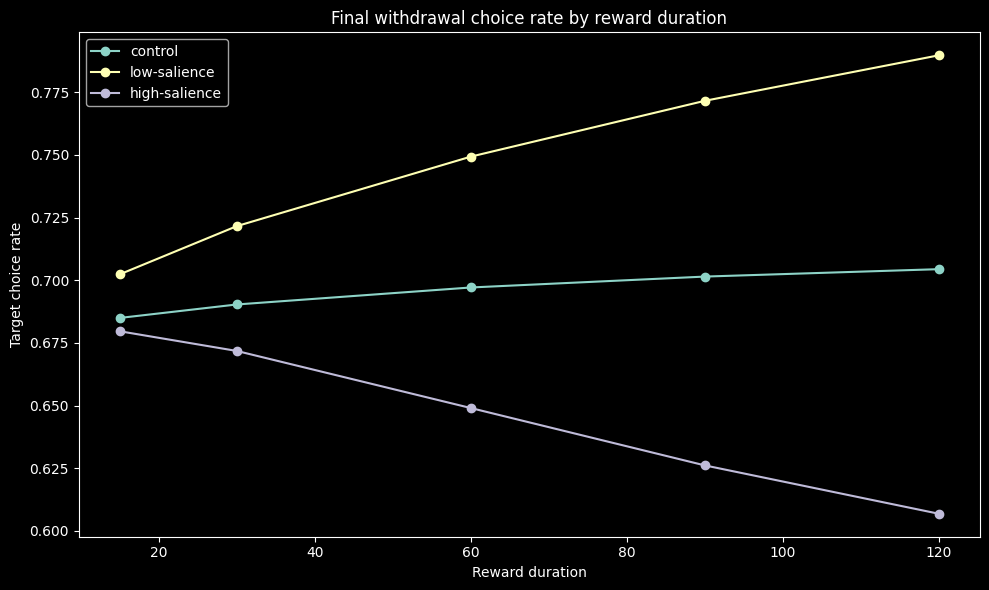

,reward-duration,"final-withdrawal-choice-rate ""control""","final-withdrawal-choice-rate ""low-salience""","final-withdrawal-choice-rate ""high-salience"""
0,15,0.684955,0.702362,0.679643
1,30,0.690327,0.721593,0.671780
2,60,0.697112,0.749341,0.648991
3,90,0.701463,0.771622,0.626094
4,120,0.704424,0.789792,0.606788


In [16]:
final_rate_summary = (
    clean_df.groupby("reward-duration")[FINAL_WITHDRAWAL_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in FINAL_WITHDRAWAL_METRICS:
    label = metric.replace('final-withdrawal-choice-rate "', "").replace('"', "")
    ax.plot(
        final_rate_summary["reward-duration"],
        final_rate_summary[metric],
        marker="o",
        label=label,
    )

ax.set_title("Final withdrawal choice rate by reward duration")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Target choice rate")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "final_withdrawal_rates_by_duration.png", dpi=200)
plt.show()

final_rate_summary

## Intrinsic motivation

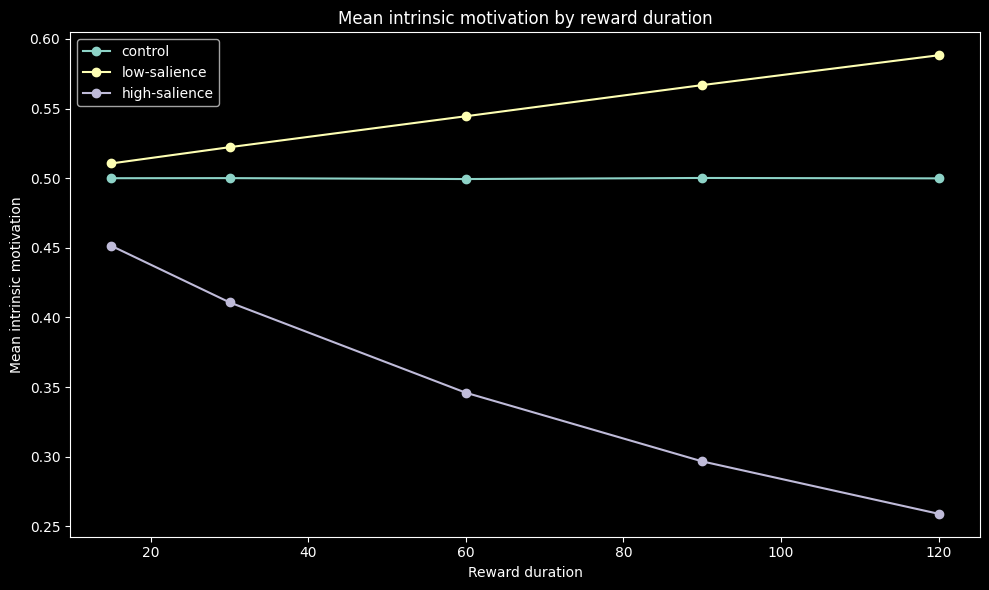

,reward-duration,"mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience"""
0,15,0.499970,0.510587,0.451363
1,30,0.500033,0.522250,0.410788
2,60,0.499380,0.544495,0.345862
3,90,0.500147,0.566861,0.296551
4,120,0.499856,0.588287,0.258924


In [17]:
motivation_summary = (
    clean_df.groupby("reward-duration")[MOTIVATION_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in MOTIVATION_METRICS:
    label = metric.replace('mean-intrinsic-motivation "', "").replace('"', "")
    ax.plot(
        motivation_summary["reward-duration"],
        motivation_summary[metric],
        marker="o",
        label=label,
    )

ax.set_title("Mean intrinsic motivation by reward duration")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Mean intrinsic motivation")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "intrinsic_motivation_by_duration.png", dpi=200)
plt.show()

motivation_summary

## Habit strength

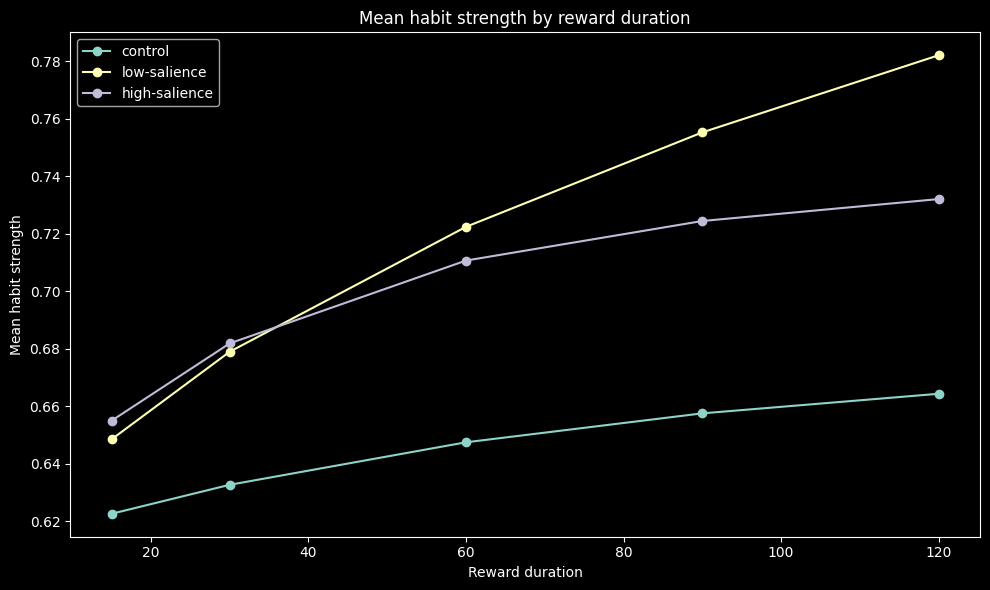

,reward-duration,"mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience"""
0,15,0.622672,0.648537,0.655021
1,30,0.632752,0.679009,0.681910
2,60,0.647529,0.722438,0.710713
3,90,0.657592,0.755278,0.724467
4,120,0.664399,0.782091,0.732095


In [18]:
habit_summary = (
    clean_df.groupby("reward-duration")[HABIT_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in HABIT_METRICS:
    label = metric.replace('mean-habit "', "").replace('"', "")
    ax.plot(
        habit_summary["reward-duration"],
        habit_summary[metric],
        marker="o",
        label=label,
    )

ax.set_title("Mean habit strength by reward duration")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Mean habit strength")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "habit_strength_by_duration.png", dpi=200)
plt.show()

habit_summary

## Retention ratio

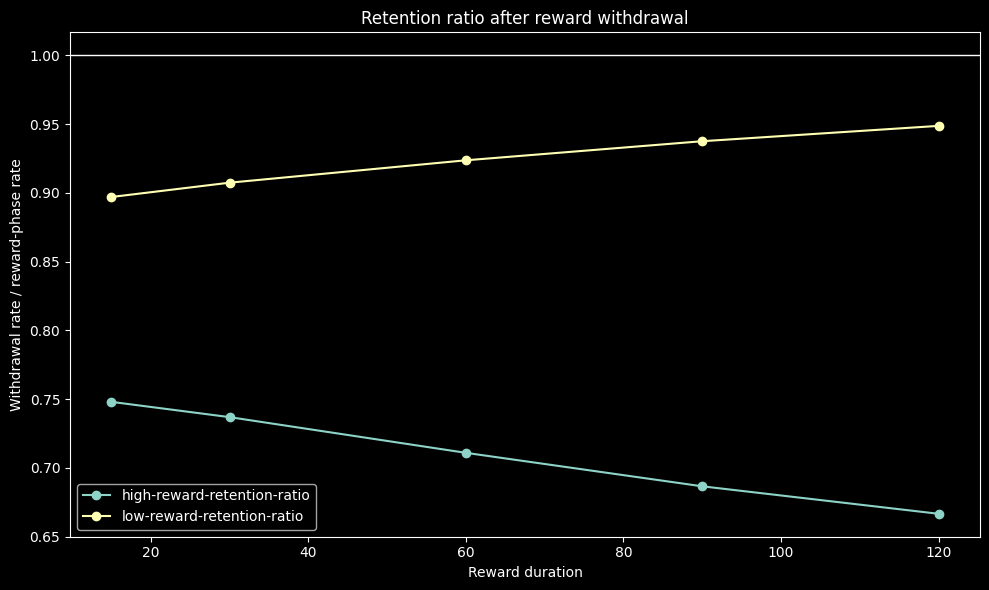

,reward-duration,high-reward-retention-ratio,low-reward-retention-ratio
0,15,0.747975,0.896937
1,30,0.736869,0.907346
2,60,0.710906,0.923627
3,90,0.686562,0.937500
4,120,0.666580,0.948662


In [19]:
retention_summary = (
    clean_df.groupby("reward-duration")[RETENTION_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in RETENTION_METRICS:
    ax.plot(
        retention_summary["reward-duration"],
        retention_summary[metric],
        marker="o",
        label=metric,
    )

ax.axhline(1, linewidth=1)
ax.set_title("Retention ratio after reward withdrawal")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Withdrawal rate / reward-phase rate")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "retention_ratio_by_duration.png", dpi=200)
plt.show()

retention_summary

## Withdrawal drop

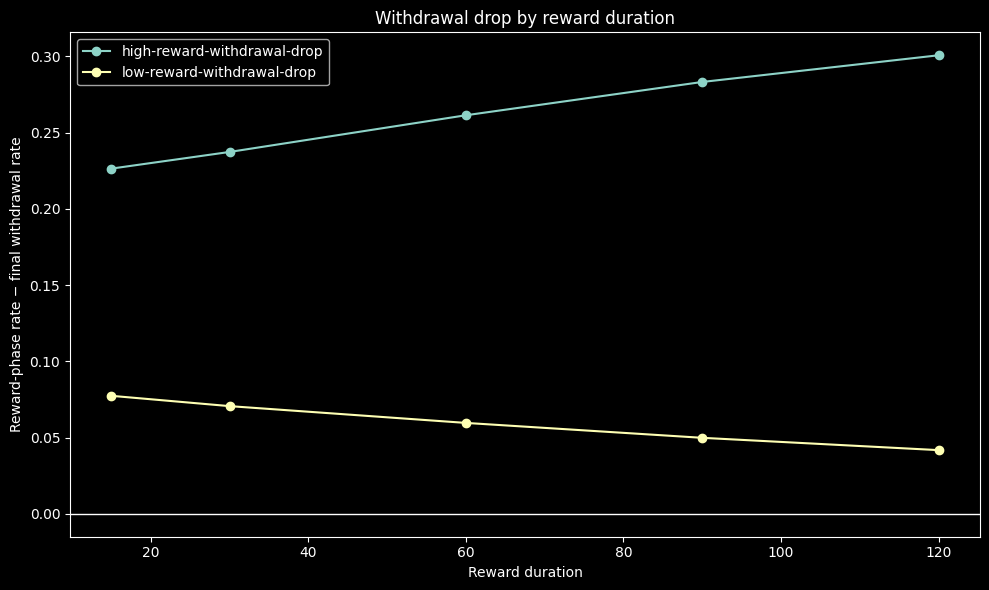

,reward-duration,high-reward-withdrawal-drop,low-reward-withdrawal-drop
0,15,0.226409,0.077381
1,30,0.237333,0.070622
2,60,0.261404,0.059607
3,90,0.283242,0.049832
4,120,0.300754,0.041754


In [20]:
withdrawal_drop_summary = (
    clean_df.groupby("reward-duration")[WITHDRAWAL_DROP_METRICS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in WITHDRAWAL_DROP_METRICS:
    ax.plot(
        withdrawal_drop_summary["reward-duration"],
        withdrawal_drop_summary[metric],
        marker="o",
        label=metric,
    )

ax.axhline(0, linewidth=1)
ax.set_title("Withdrawal drop by reward duration")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Reward-phase rate − final withdrawal rate")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "withdrawal_drop_by_duration.png", dpi=200)
plt.show()

withdrawal_drop_summary

## Heatmaps

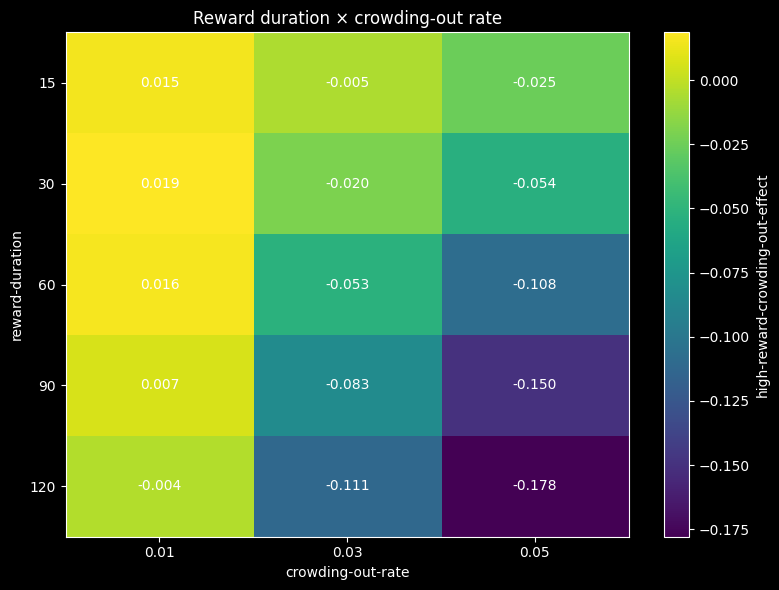

crowding-out-rate,0.01,0.03,0.05
reward-duration,,,
15,0.014842,-0.005494,-0.025285
30,0.018569,-0.020297,-0.053915
60,0.016082,-0.052798,-0.107645
90,0.006559,-0.083123,-0.149543
120,-0.003768,-0.111258,-0.177885


In [21]:
pivot_duration_crowding = clean_df.pivot_table(
    values=PRIMARY_TARGET,
    index="reward-duration",
    columns="crowding-out-rate",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(pivot_duration_crowding.values, aspect="auto")

ax.set_xticks(range(len(pivot_duration_crowding.columns)))
ax.set_xticklabels(pivot_duration_crowding.columns)
ax.set_yticks(range(len(pivot_duration_crowding.index)))
ax.set_yticklabels(pivot_duration_crowding.index)
ax.set_xlabel("crowding-out-rate")
ax.set_ylabel("reward-duration")
ax.set_title("Reward duration × crowding-out rate")

for row in range(pivot_duration_crowding.shape[0]):
    for column in range(pivot_duration_crowding.shape[1]):
        value = pivot_duration_crowding.iloc[row, column]
        ax.text(column, row, f"{value:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label=PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_duration_vs_crowding.png", dpi=200)
plt.show()

pivot_duration_crowding

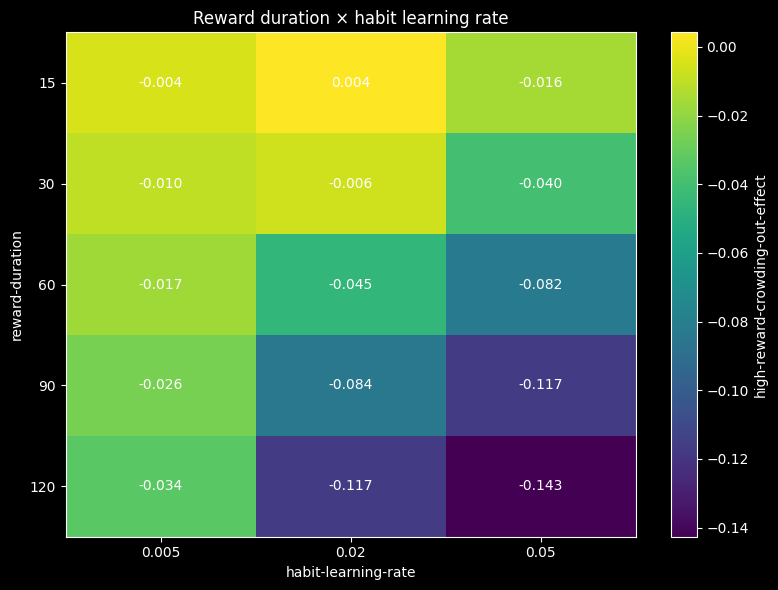

habit-learning-rate,0.005,0.020,0.050
reward-duration,,,
15,-0.004492,0.004271,-0.015715
30,-0.009625,-0.006281,-0.039737
60,-0.016963,-0.045477,-0.081921
90,-0.025829,-0.083561,-0.116717
120,-0.033576,-0.116656,-0.142679


In [22]:
pivot_duration_habit = clean_df.pivot_table(
    values=PRIMARY_TARGET,
    index="reward-duration",
    columns="habit-learning-rate",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(pivot_duration_habit.values, aspect="auto")

ax.set_xticks(range(len(pivot_duration_habit.columns)))
ax.set_xticklabels(pivot_duration_habit.columns)
ax.set_yticks(range(len(pivot_duration_habit.index)))
ax.set_yticklabels(pivot_duration_habit.index)
ax.set_xlabel("habit-learning-rate")
ax.set_ylabel("reward-duration")
ax.set_title("Reward duration × habit learning rate")

for row in range(pivot_duration_habit.shape[0]):
    for column in range(pivot_duration_habit.shape[1]):
        value = pivot_duration_habit.iloc[row, column]
        ax.text(column, row, f"{value:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label=PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_duration_vs_habit.png", dpi=200)
plt.show()

pivot_duration_habit

## Factorial ANOVA

In [23]:
anova_df = clean_df.rename(columns={
    "reward-duration": "reward_duration",
    "high-reward-salience": "high_reward_salience",
    "crowding-out-rate": "crowding_out_rate",
    "habit-learning-rate": "habit_learning_rate",
    PRIMARY_TARGET: "crowding_effect",
})

formula = (
    "crowding_effect ~ "
    "C(reward_duration) + "
    "C(high_reward_salience) + "
    "C(crowding_out_rate) + "
    "C(habit_learning_rate) + "
    "C(reward_duration):C(high_reward_salience) + "
    "C(reward_duration):C(crowding_out_rate) + "
    "C(reward_duration):C(habit_learning_rate) + "
    "C(high_reward_salience):C(crowding_out_rate) + "
    "C(high_reward_salience):C(habit_learning_rate) + "
    "C(crowding_out_rate):C(habit_learning_rate)"
)

anova_model = smf.ols(formula, data=anova_df).fit()
anova_table = anova_lm(anova_model, typ=2)

anova_table["eta_squared"] = (
    anova_table["sum_sq"] / anova_table["sum_sq"].sum()
)

anova_table = anova_table.sort_values(
    "eta_squared",
    ascending=False,
)

anova_table.to_csv(
    OUTPUT_DIR / "factorial_anova_reward_duration_v2.csv"
)

anova_table

,sum_sq,df,F,PR(>F),eta_squared
C(crowding_out_rate),5.820075,2.0,19556.322755,0.000000e+00,0.315976
C(high_reward_salience),3.697277,2.0,12423.401380,0.000000e+00,0.200728
C(reward_duration),3.184699,4.0,5350.532147,0.000000e+00,0.172900
C(habit_learning_rate),1.688973,2.0,5675.201402,0.000000e+00,0.091696
C(reward_duration):C(crowding_out_rate),1.170158,8.0,982.976314,0.000000e+00,0.063529
C(high_reward_salience):C(crowding_out_rate),0.792776,4.0,1331.923057,0.000000e+00,0.043040
C(reward_duration):C(high_reward_salience),0.783218,8.0,657.932124,0.000000e+00,0.042521
C(reward_duration):C(habit_learning_rate),0.781585,8.0,656.560544,0.000000e+00,0.042433
Residual,0.394774,2653.0,NaN,NaN,0.021433
C(crowding_out_rate):C(habit_learning_rate),0.102500,4.0,172.207702,2.887346e-131,0.005565


## Діагностика ANOVA

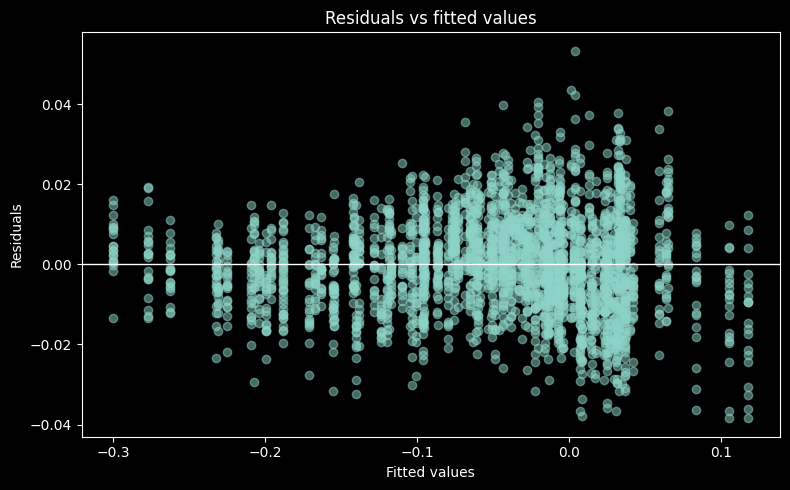

In [24]:
residuals = anova_model.resid
fitted = anova_model.fittedvalues

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, residuals, alpha=0.5)
ax.axhline(0, linewidth=1)
ax.set_title("Residuals vs fitted values")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "anova_residuals_vs_fitted.png", dpi=200)
plt.show()

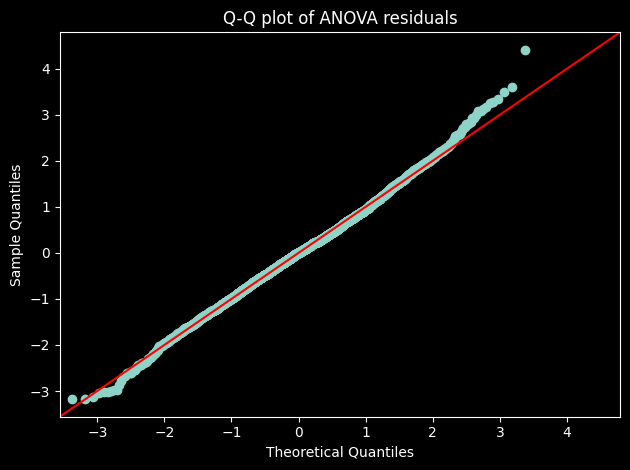

In [25]:
fig = sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q plot of ANOVA residuals")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "anova_residuals_qq.png", dpi=200)
plt.show()

## Random Forest та permutation importance

In [26]:
X = clean_df[FACTORS].copy()
y = clean_df[PRIMARY_TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=1,
)

rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

print("R²:", round(r2_score(y_test, predictions), 4))
print("MAE:", round(mean_absolute_error(y_test, predictions), 4))

R²: 0.9836
MAE: 0.0081


In [27]:
permutation = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2",
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "parameter": FACTORS,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(
    OUTPUT_DIR / "permutation_importance_reward_duration_v2.csv",
    index=False,
)

importance_df

,parameter,importance_mean,importance_std
2,crowding-out-rate,0.870388,0.056671
0,reward-duration,0.692053,0.029603
1,high-reward-salience,0.581794,0.036707
3,habit-learning-rate,0.288898,0.016302


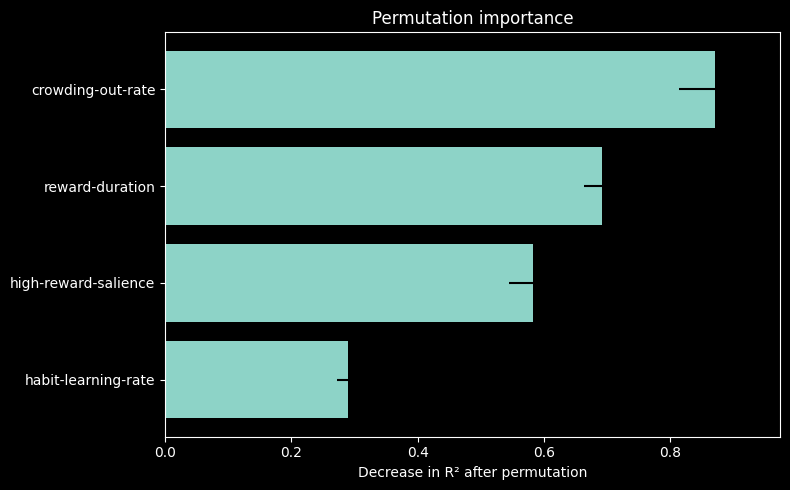

In [28]:
ordered = importance_df.sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    ordered["parameter"],
    ordered["importance_mean"],
    xerr=ordered["importance_std"],
)
ax.set_title("Permutation importance")
ax.set_xlabel("Decrease in R² after permutation")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=200)
plt.show()

## Partial dependence

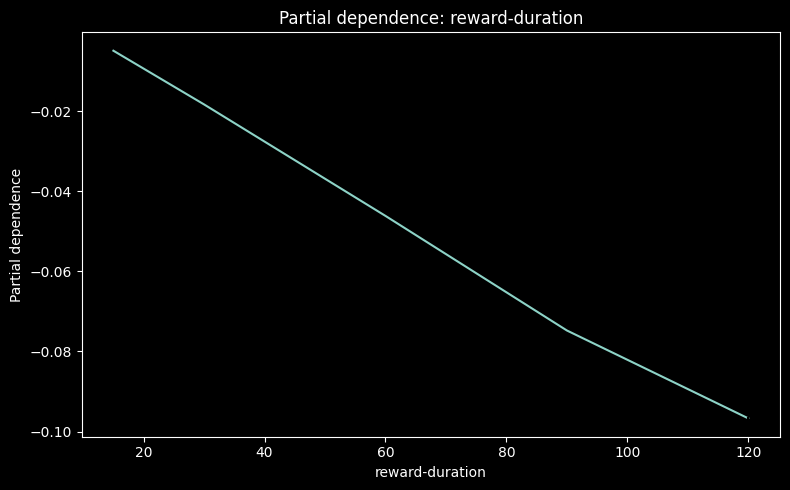

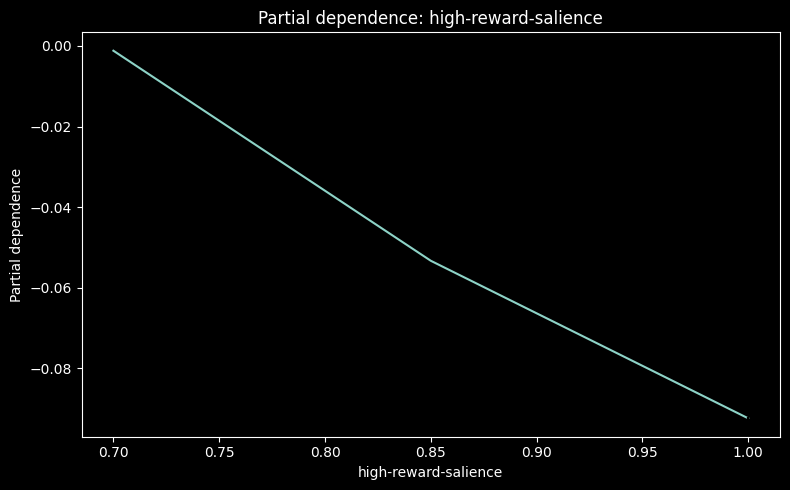

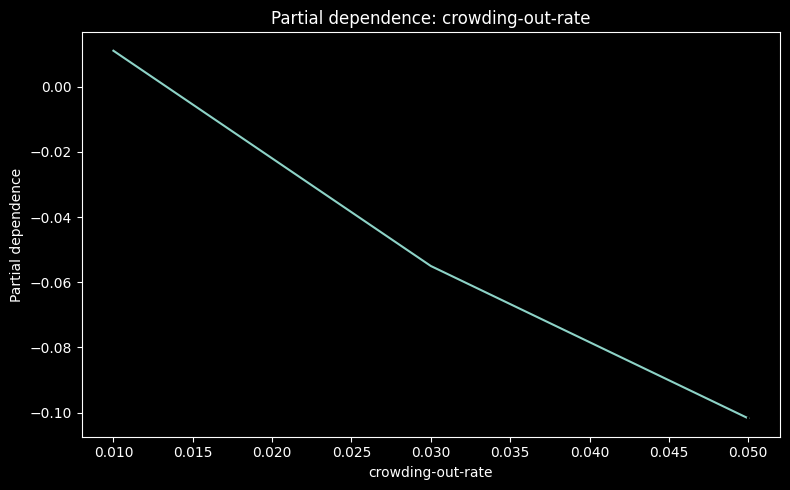

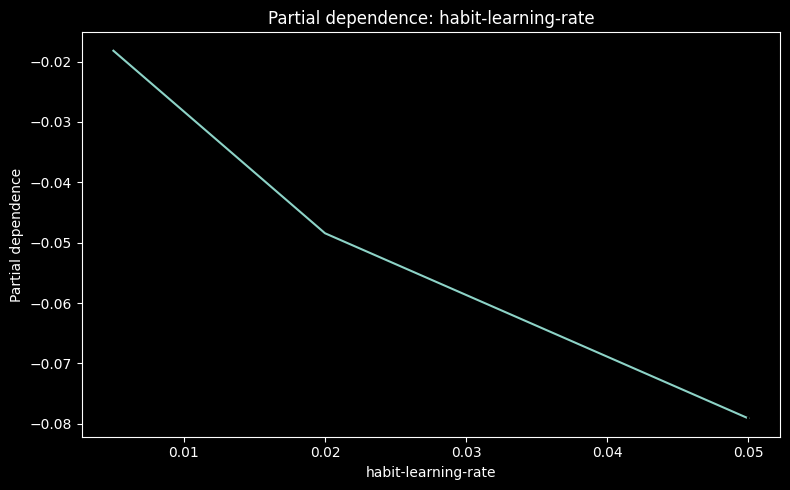

In [29]:
for factor in FACTORS:
    fig, ax = plt.subplots(figsize=(8, 5))

    PartialDependenceDisplay.from_estimator(
        rf,
        X_train,
        [factor],
        ax=ax,
    )

    ax.set_title(f"Partial dependence: {factor}")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"partial_dependence_{factor}.png",
        dpi=200,
    )
    plt.show()

## Підсумок сценаріїв

In [30]:
scenario_summary = (
    clean_df.groupby(FACTORS)
    .agg(
        mean_crowding_effect=(PRIMARY_TARGET, "mean"),
        std_crowding_effect=(PRIMARY_TARGET, "std"),
        mean_low_persistence=(SECONDARY_TARGET, "mean"),
        mean_high_retention=("high-reward-retention-ratio", "mean"),
        mean_low_retention=("low-reward-retention-ratio", "mean"),
        mean_high_withdrawal_drop=("high-reward-withdrawal-drop", "mean"),
        mean_low_withdrawal_drop=("low-reward-withdrawal-drop", "mean"),
        crowding_probability=(
            PRIMARY_TARGET,
            lambda values: (values < 0).mean(),
        ),
        runs=(PRIMARY_TARGET, "size"),
    )
    .reset_index()
)

scenario_summary.to_csv(
    OUTPUT_DIR / "scenario_summary_reward_duration_v2.csv",
    index=False,
)

print("Сценарії з найсильнішим crowding-out:")
display(
    scenario_summary
    .sort_values("mean_crowding_effect")
    .head(10)
)

print("Сценарії з найкращим post-program effect:")
display(
    scenario_summary
    .sort_values("mean_crowding_effect", ascending=False)
    .head(10)
)

Сценарії з найсильнішим crowding-out:


,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,mean_high_withdrawal_drop,mean_low_withdrawal_drop,crowding_probability,runs
134,120,1.00,0.05,0.050,-0.294940,0.006618,0.048128,0.544727,0.950937,0.420728,0.043679,1.0,20
133,120,1.00,0.05,0.020,-0.275128,0.009551,0.073796,0.530161,0.971143,0.429705,0.024782,1.0,20
107,90,1.00,0.05,0.050,-0.263866,0.006339,0.037323,0.574450,0.944915,0.396596,0.048770,1.0,20
106,90,1.00,0.05,0.020,-0.235458,0.007955,0.067785,0.560500,0.968489,0.404684,0.026661,1.0,20
125,120,0.85,0.05,0.050,-0.233646,0.006945,0.049270,0.614079,0.950262,0.353915,0.044283,1.0,20
131,120,1.00,0.03,0.050,-0.230796,0.006560,0.048105,0.603069,0.949909,0.372360,0.044536,1.0,20
124,120,0.85,0.05,0.020,-0.214262,0.008672,0.073929,0.602864,0.971733,0.359481,0.024263,1.0,20
130,120,1.00,0.03,0.020,-0.207309,0.008122,0.076360,0.591654,0.971208,0.379946,0.024737,1.0,20
80,60,1.00,0.05,0.050,-0.207232,0.005475,0.026978,0.626641,0.939645,0.351311,0.052915,1.0,20
132,120,1.00,0.05,0.005,-0.206060,0.009312,0.132366,0.411646,0.925710,0.502914,0.055384,1.0,20


Сценарії з найкращим post-program effect:


,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,mean_high_withdrawal_drop,mean_low_withdrawal_drop,crowding_probability,runs
108,120,0.70,0.01,0.005,0.103772,0.014299,0.134167,0.763703,0.924674,0.204352,0.056256,0.0,20
81,90,0.70,0.01,0.005,0.094293,0.012634,0.105216,0.754917,0.896920,0.210319,0.075703,0.0,20
117,120,0.85,0.01,0.005,0.077891,0.011841,0.134753,0.707491,0.924000,0.261082,0.056600,0.0,20
54,60,0.70,0.01,0.005,0.076016,0.012848,0.079932,0.739233,0.873594,0.221647,0.091484,0.0,20
90,90,0.85,0.01,0.005,0.065958,0.010729,0.102237,0.700427,0.900171,0.265519,0.072870,0.0,20
63,60,0.85,0.01,0.005,0.059826,0.013626,0.068640,0.695687,0.869252,0.268791,0.093761,0.0,20
99,90,1.00,0.01,0.005,0.048214,0.010225,0.106120,0.660659,0.899704,0.309555,0.073620,0.0,20
126,120,1.00,0.01,0.005,0.046617,0.013490,0.130241,0.659491,0.923350,0.311997,0.057097,0.0,20
72,60,1.00,0.01,0.005,0.043446,0.009592,0.074612,0.656180,0.869037,0.312302,0.094522,0.0,20
27,30,0.70,0.01,0.005,0.043002,0.011240,0.035760,0.711047,0.835904,0.243228,0.116091,0.0,20


## Стабільні режими

In [31]:
stable_crowding = (
    scenario_summary[
        (scenario_summary["mean_crowding_effect"] < 0)
        & (scenario_summary["crowding_probability"] >= 0.80)
    ]
    .sort_values(
        ["crowding_probability", "mean_crowding_effect"],
        ascending=[False, True],
    )
)

stable_persistence = (
    scenario_summary[
        (scenario_summary["mean_crowding_effect"] > 0)
        & (scenario_summary["crowding_probability"] <= 0.20)
    ]
    .sort_values("mean_crowding_effect", ascending=False)
)

print("Stable crowding-out scenarios:", len(stable_crowding))
display(stable_crowding.head(20))

print("Stable persistence scenarios:", len(stable_persistence))
display(stable_persistence.head(20))

Stable crowding-out scenarios: 86


,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,mean_high_withdrawal_drop,mean_low_withdrawal_drop,crowding_probability,runs
134,120,1.00,0.05,0.050,-0.294940,0.006618,0.048128,0.544727,0.950937,0.420728,0.043679,1.0,20
133,120,1.00,0.05,0.020,-0.275128,0.009551,0.073796,0.530161,0.971143,0.429705,0.024782,1.0,20
107,90,1.00,0.05,0.050,-0.263866,0.006339,0.037323,0.574450,0.944915,0.396596,0.048770,1.0,20
106,90,1.00,0.05,0.020,-0.235458,0.007955,0.067785,0.560500,0.968489,0.404684,0.026661,1.0,20
125,120,0.85,0.05,0.050,-0.233646,0.006945,0.049270,0.614079,0.950262,0.353915,0.044283,1.0,20
131,120,1.00,0.03,0.050,-0.230796,0.006560,0.048105,0.603069,0.949909,0.372360,0.044536,1.0,20
124,120,0.85,0.05,0.020,-0.214262,0.008672,0.073929,0.602864,0.971733,0.359481,0.024263,1.0,20
130,120,1.00,0.03,0.020,-0.207309,0.008122,0.076360,0.591654,0.971208,0.379946,0.024737,1.0,20
80,60,1.00,0.05,0.050,-0.207232,0.005475,0.026978,0.626641,0.939645,0.351311,0.052915,1.0,20
132,120,1.00,0.05,0.005,-0.206060,0.009312,0.132366,0.411646,0.925710,0.502914,0.055384,1.0,20


Stable persistence scenarios: 33


,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,mean_high_withdrawal_drop,mean_low_withdrawal_drop,crowding_probability,runs
108,120,0.70,0.01,0.005,0.103772,0.014299,0.134167,0.763703,0.924674,0.204352,0.056256,0.0,20
81,90,0.70,0.01,0.005,0.094293,0.012634,0.105216,0.754917,0.896920,0.210319,0.075703,0.0,20
117,120,0.85,0.01,0.005,0.077891,0.011841,0.134753,0.707491,0.924000,0.261082,0.056600,0.0,20
54,60,0.70,0.01,0.005,0.076016,0.012848,0.079932,0.739233,0.873594,0.221647,0.091484,0.0,20
90,90,0.85,0.01,0.005,0.065958,0.010729,0.102237,0.700427,0.900171,0.265519,0.072870,0.0,20
63,60,0.85,0.01,0.005,0.059826,0.013626,0.068640,0.695687,0.869252,0.268791,0.093761,0.0,20
99,90,1.00,0.01,0.005,0.048214,0.010225,0.106120,0.660659,0.899704,0.309555,0.073620,0.0,20
126,120,1.00,0.01,0.005,0.046617,0.013490,0.130241,0.659491,0.923350,0.311997,0.057097,0.0,20
72,60,1.00,0.01,0.005,0.043446,0.009592,0.074612,0.656180,0.869037,0.312302,0.094522,0.0,20
27,30,0.70,0.01,0.005,0.043002,0.011240,0.035760,0.711047,0.835904,0.243228,0.116091,0.0,20


## Результати за reward duration

In [32]:
duration_outcomes = (
    clean_df.groupby("reward-duration")
    .agg(
        mean_crowding_effect=(PRIMARY_TARGET, "mean"),
        mean_low_persistence=(SECONDARY_TARGET, "mean"),
        mean_high_retention=("high-reward-retention-ratio", "mean"),
        mean_high_withdrawal_drop=("high-reward-withdrawal-drop", "mean"),
        crowding_probability=(
            PRIMARY_TARGET,
            lambda values: (values < 0).mean(),
        ),
    )
    .reset_index()
)

duration_outcomes

,reward-duration,mean_crowding_effect,mean_low_persistence,mean_high_retention,mean_high_withdrawal_drop,crowding_probability
0,15,-0.005312,0.017407,0.747975,0.226409,0.524074
1,30,-0.018548,0.031265,0.736869,0.237333,0.616667
2,60,-0.048120,0.052229,0.710906,0.261404,0.709259
3,90,-0.075369,0.070159,0.686562,0.283242,0.790741
4,120,-0.097637,0.085368,0.666580,0.300754,0.814815


## Автоматичне резюме

In [33]:
crowding_share = (clean_df[PRIMARY_TARGET] < 0).mean()

most_important = importance_df.iloc[0]["parameter"]
largest_anova_effect = anova_table.index[0]

best_duration = (
    duration_outcomes
    .sort_values("mean_crowding_effect", ascending=False)
    .iloc[0]
)

worst_duration = (
    duration_outcomes
    .sort_values("mean_crowding_effect")
    .iloc[0]
)

best_scenario = (
    scenario_summary
    .sort_values("mean_crowding_effect", ascending=False)
    .iloc[0]
)

worst_scenario = (
    scenario_summary
    .sort_values("mean_crowding_effect")
    .iloc[0]
)

print("Mean high-reward crowding-out effect:",
      round(clean_df[PRIMARY_TARGET].mean(), 4))
print("Share of runs with crowding-out:",
      f"{crowding_share:.1%}")
print("Most important parameter:",
      most_important)
print("Largest ANOVA effect:",
      largest_anova_effect)
print("Best reward duration:",
      int(best_duration["reward-duration"]),
      round(best_duration["mean_crowding_effect"], 4))
print("Worst reward duration:",
      int(worst_duration["reward-duration"]),
      round(worst_duration["mean_crowding_effect"], 4))

print("\nBest parameter combination:")
display(best_scenario.to_frame().T)

print("Worst parameter combination:")
display(worst_scenario.to_frame().T)

Mean high-reward crowding-out effect: -0.049
Share of runs with crowding-out: 69.1%
Most important parameter: crowding-out-rate
Largest ANOVA effect: C(crowding_out_rate)
Best reward duration: 15 -0.0053
Worst reward duration: 120 -0.0976

Best parameter combination:


,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,mean_high_withdrawal_drop,mean_low_withdrawal_drop,crowding_probability,runs
108,120.0,0.7,0.01,0.005,0.103772,0.014299,0.134167,0.763703,0.924674,0.204352,0.056256,0.0,20.0


Worst parameter combination:


,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,mean_high_withdrawal_drop,mean_low_withdrawal_drop,crowding_probability,runs
134,120.0,1.0,0.05,0.05,-0.29494,0.006618,0.048128,0.544727,0.950937,0.420728,0.043679,1.0,20.0


## Експорт результатів

In [34]:
clean_df.to_csv(
    OUTPUT_DIR / "clean_reward_duration_v2_data.csv",
    index=False,
)

duration_summary.to_csv(
    OUTPUT_DIR / "main_effect_reward_duration.csv",
    index=False,
)

duration_outcomes.to_csv(
    OUTPUT_DIR / "duration_outcomes_summary.csv",
    index=False,
)

motivation_summary.to_csv(
    OUTPUT_DIR / "motivation_summary_by_duration.csv",
    index=False,
)

habit_summary.to_csv(
    OUTPUT_DIR / "habit_summary_by_duration.csv",
    index=False,
)

retention_summary.to_csv(
    OUTPUT_DIR / "retention_summary_by_duration.csv",
    index=False,
)

withdrawal_drop_summary.to_csv(
    OUTPUT_DIR / "withdrawal_drop_summary_by_duration.csv",
    index=False,
)

print("Усі результати збережено у:")
print(OUTPUT_DIR.resolve())

Усі результати збережено у:
/Users/igor/projects/phd/reward-habits-model/analysis_output/2-reward_duration


In [41]:
scenario_summary.sort_values(
    "mean_crowding_effect",
    ascending=False
).head(10)

,reward-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,mean_high_withdrawal_drop,mean_low_withdrawal_drop,crowding_probability,runs
108,120,0.70,0.01,0.005,0.103772,0.014299,0.134167,0.763703,0.924674,0.204352,0.056256,0.0,20
81,90,0.70,0.01,0.005,0.094293,0.012634,0.105216,0.754917,0.896920,0.210319,0.075703,0.0,20
117,120,0.85,0.01,0.005,0.077891,0.011841,0.134753,0.707491,0.924000,0.261082,0.056600,0.0,20
54,60,0.70,0.01,0.005,0.076016,0.012848,0.079932,0.739233,0.873594,0.221647,0.091484,0.0,20
90,90,0.85,0.01,0.005,0.065958,0.010729,0.102237,0.700427,0.900171,0.265519,0.072870,0.0,20
63,60,0.85,0.01,0.005,0.059826,0.013626,0.068640,0.695687,0.869252,0.268791,0.093761,0.0,20
99,90,1.00,0.01,0.005,0.048214,0.010225,0.106120,0.660659,0.899704,0.309555,0.073620,0.0,20
126,120,1.00,0.01,0.005,0.046617,0.013490,0.130241,0.659491,0.923350,0.311997,0.057097,0.0,20
72,60,1.00,0.01,0.005,0.043446,0.009592,0.074612,0.656180,0.869037,0.312302,0.094522,0.0,20
27,30,0.70,0.01,0.005,0.043002,0.011240,0.035760,0.711047,0.835904,0.243228,0.116091,0.0,20
